### Load packages

In [52]:
# Load all required libraries
import warnings
warnings.filterwarnings('ignore')

import sys
import pathlib
from pathlib import Path
import pickle
import os
import numpy as np
import pandas as pd
from netCDF4 import Dataset as NetCDFFile 
import import_ipynb
from datetime import date, datetime, timedelta
import datetime as dt
# import oceans.sw_extras as swe
import gsw
import matplotlib.pyplot as plt
import timezonefinder, pytz
tf = timezonefinder.TimezoneFinder()
from sklearn.metrics import r2_score, mean_squared_error
import math

# Import SOCA ligh model funtions
import import_ipynb
from FUNCTIONS.OTHER_FUNCTIONS import rad_date, rad_LC_hour, derive_ZPD,find_MLD
from FUNCTIONS.PAR_ADJUSTED_FUNCTION import PAR_ADJUSTED_profiles
from FUNCTIONS.ED380_ADJUSTED_FUNCTION import ED380_ADJUSTED_profiles
from FUNCTIONS.ED412_ADJUSTED_FUNCTION import ED412_ADJUSTED_profiles
from FUNCTIONS.ED490_ADJUSTED_FUNCTION import ED490_ADJUSTED_profiles

### Define analysis functions

In [148]:
def SOCA_LIGHT_SRDL(output_folder_name, input_sat_matchup_file_path):
    # Model output directories
    curr_work_dir = Path.cwd()
    PAR_OUT_PATH_MEOP = (''.join([str(curr_work_dir),'/OUTPUTS/PAR/',output_folder_name]))
    ED380_OUT_PATH_MEOP = (''.join([str(curr_work_dir),'/OUTPUTS/ED380/',output_folder_name]))
    ED412_OUT_PATH_MEOP = (''.join([str(curr_work_dir),'/OUTPUTS/ED412/',output_folder_name]))
    ED490_OUT_PATH_MEOP = (''.join([str(curr_work_dir),'/OUTPUTS/ED490/',output_folder_name]))
    # Create folders if they do not exist
    Path(PAR_OUT_PATH_MEOP).mkdir(parents=True, exist_ok=True)
    Path(ED380_OUT_PATH_MEOP).mkdir(parents=True, exist_ok=True)
    Path(ED412_OUT_PATH_MEOP).mkdir(parents=True, exist_ok=True)
    Path(ED490_OUT_PATH_MEOP).mkdir(parents=True, exist_ok=True)

    # Satellite matchup input file
    input_file_name = (''.join([str(curr_work_dir),input_sat_matchup_file_path]))
    Inputs=pd.read_csv(str(input_file_name))

    for i in np.arange(len(Inputs)):
        # Inputs from satellite match up file
        SEALTAG_NC_FILE = Inputs.SEALTAG_NC_FILE[i]
        PROFILE = Inputs.PROFILE_NUM[i]
        RHO412 = Inputs.RRS412[i]
        RHO443 = Inputs.RRS443[i]
        RHO490 = Inputs.RRS490[i]
        RHO555 = Inputs.RRS555[i]
        RHO670 = Inputs.RRS670[i]
        PAR = Inputs.PAR[i]
        KD490 = Inputs.KD490[i]
        
        # Define output file names
        SAT = Inputs.SATELLITE[i].replace('_','')
        PAR_output_file = (''.join([str(PAR_OUT_PATH_MEOP),'/',str(Inputs.TAG_ID[i]),'_',str(PROFILE),'_',str(SAT),'_PAR.txt']))
        ED380_output_file = (''.join([str(ED380_OUT_PATH_MEOP),'/',str(Inputs.TAG_ID[i]),'_',str(PROFILE),'_',str(SAT),'_ED380.txt']))
        ED412_output_file = (''.join([str(ED412_OUT_PATH_MEOP),'/',str(Inputs.TAG_ID[i]),'_',str(PROFILE),'_',str(SAT),'_ED412.txt']))
        ED490_output_file = (''.join([str(ED490_OUT_PATH_MEOP),'/',str(Inputs.TAG_ID[i]),'_',str(PROFILE),'_',str(SAT),'_ED490.txt']))
        # Check if this file already exists, if yes, append _2 to file name. If _2 exists, append _3 and so on.
        count = 1
        while os.path.isfile(PAR_output_file):
            count += 1
            PAR_output_file = PAR_output_file.replace(str(SAT), ''.join([str(SAT),'_GRAN{}']).format(count))
        count = 1
        while os.path.isfile(ED380_output_file):
            count += 1
            ED380_output_file = ED380_output_file.replace(str(SAT), ''.join([str(SAT),'_GRAN{}']).format(count))
        count = 1
        while os.path.isfile(ED412_output_file):
            count += 1
            ED412_output_file = ED412_output_file.replace(str(SAT), ''.join([str(SAT),'_GRAN{}']).format(count))
        count = 1
        while os.path.isfile(ED490_output_file):
            count += 1
            ED490_output_file = ED490_output_file.replace(str(SAT), ''.join([str(SAT),'_GRAN{}']).format(count))
        
        if os.path.isfile(SEALTAG_NC_FILE): # check Argo file exist
            # LOAD THE SEALTAG file
            #######################################################################################
            # ADD the path of the SEALTAG NC file
            NC= NetCDFFile(str(SEALTAG_NC_FILE))
            # Read ProfileInfo excel file
            profile_info_file = SEALTAG_NC_FILE.replace('_PROCESSED.nc','_ProfileInfo.xlsx')
            profile_info = pd.read_excel(profile_info_file, sheet_name='General')
        
            #######################################################################################
            ##### EXTRACTING TEMP SAL PRES same depths FROM NC ARGO FILE ##########################
            #######################################################################################
            pres_1 = NC.variables['PRES'][PROFILE-1,:]
            temp_1 = NC.variables['TEMP'][PROFILE-1,:]
            sal_1 = NC.variables['PSAL'][PROFILE-1,:]
            pres2 = pres_1.filled(fill_value=np.nan)
            temp2 = temp_1.filled(fill_value=np.nan)
            sal2 = sal_1.filled(fill_value=np.nan)
            
            LAT = float(profile_info.Lat[PROFILE-1])
            LON = float(profile_info.Lon[PROFILE-1])
            
            ########################################################################################
            # Declare output depths
            depth_output = np.linspace(0,250,51)
            #######################################################################################

            pres3=pres2[pres2<=250] # Light profile computed if T/S have at least 10 good points in 0 to 250 m water column
            pres3=pres2[pres2<=250] # Light profile computed if T/S have at least 15 good points in 0 to 250 m water column
            pres4=pres2[pres2<=50] # Light profile computed if T/S have at least 5 good points in 0 to 50 m water column
            if (len(pres3)>=15) & (len(pres4)>=5): # selected T/S profiles qualified above criterias
                #######################################################################################
                ##### EXTRACTING MLD ##################################################################
                #######################################################################################
                # Read MLD from ProfileInfo excel file
                MLD_1 = -profile_info.MLD[PROFILE-1]
                # print('MLD is :', MLD_1,'m')
        
                #######################################################################################
                ##### EXTRACTING DOY FROM NC ARGO FILE ################################################
                #######################################################################################
                JULD = NC.variables['JULD'][PROFILE-1]
                # #Get day, month, year from juld
                ref_date = datetime(1950, 1, 1)
                date_prof = ref_date + timedelta(days=float(JULD))
                year_prof = date_prof.strftime('%Y')
                month_prof = date_prof.strftime('%m')
                day_prof = date_prof.strftime('%d')
                DOY = int(date_prof.strftime('%j'))
                # print(date_prof)
                # No need to change anything in this section by the user
                sin_doy = np.sin(rad_date(DOY))
                cos_doy = np.cos(rad_date(DOY))

                ########################################################################################################
                # Extract local time from the nc file and convert into radiance and then transform into Sine and Cosine
                ########################################################################################################
                timezone_str = tf.certain_timezone_at(lat=LAT, lng=LON)
                timezone = pytz.timezone(timezone_str)
                # date_prof is in GMT time scale
                LC = date_prof + timezone.utcoffset(date_prof) # +
                GMT_Hour = date_prof.strftime('%H')
                LC_Hour = LC.strftime('%H') 

                GMT_Hour_Min = date_prof.strftime('%H:%M')
                LC_Hour_Min = LC.strftime('%H:%M')  
                LC_Hour_Deci = (int(LC_Hour_Min[0:2]) + int(LC_Hour_Min[3:])/60)

                # LC_hour = 12
                sin_LC_hour = np.sin(rad_LC_hour(LC_Hour_Deci))
                cos_LC_hour = np.cos(rad_LC_hour(LC_Hour_Deci))
                ####################################################################################### 
                #######################################################################################
                # No need to change anything in this section by the user
                # HOW to use this function
        
                if(not np.isnan(MLD_1) and not np.isnan(PAR) and not np.isnan(KD490)and
                    not np.isnan(RHO412) and not np.isnan(RHO443) and not np.isnan(RHO490) and
                    not np.isnan(RHO555) and not np.isnan(RHO670)):
                    PAR_ADJUSTED=PAR_ADJUSTED_profiles(PAR=PAR, MLD=MLD_1, ZPD=derive_ZPD(float(KD490)), RHO_WN_412=RHO412, RHO_WN_443=RHO443,
                                                        RHO_WN_490=RHO490, RHO_WN_555=RHO555, RHO_WN_670=RHO670, sin_doy=sin_doy,
                                                        cos_doy=cos_doy, sin_LC_hour=sin_LC_hour, cos_LC_hour=cos_LC_hour,
                                                        temp=temp2, sal=sal2, depths_argo=pres2, depth_output=depth_output)[0]
                    ED380_ADJUSTED=ED380_ADJUSTED_profiles(PAR=PAR, MLD=MLD_1, ZPD=derive_ZPD(float(KD490)), RHO_WN_412=RHO412, RHO_WN_443=RHO443,
                                                        RHO_WN_490=RHO490, RHO_WN_555=RHO555, RHO_WN_670=RHO670, sin_doy=sin_doy,
                                                        cos_doy=cos_doy, sin_LC_hour=sin_LC_hour, cos_LC_hour=cos_LC_hour,
                                                        temp=temp2, sal=sal2, depths_argo=pres2, depth_output=depth_output)[0]
                    ED412_ADJUSTED=ED412_ADJUSTED_profiles(PAR=PAR, MLD=MLD_1, ZPD=derive_ZPD(float(KD490)), RHO_WN_412=RHO412, RHO_WN_443=RHO443,
                                                        RHO_WN_490=RHO490, RHO_WN_555=RHO555, RHO_WN_670=RHO670, sin_doy=sin_doy,
                                                        cos_doy=cos_doy, sin_LC_hour=sin_LC_hour, cos_LC_hour=cos_LC_hour,
                                                        temp=temp2, sal=sal2, depths_argo=pres2, depth_output=depth_output)[0]
                    ED490_ADJUSTED=ED490_ADJUSTED_profiles(PAR=PAR, MLD=MLD_1, ZPD=derive_ZPD(float(KD490)), RHO_WN_412=RHO412, RHO_WN_443=RHO443,
                                                        RHO_WN_490=RHO490, RHO_WN_555=RHO555, RHO_WN_670=RHO670, sin_doy=sin_doy,
                                                        cos_doy=cos_doy, sin_LC_hour=sin_LC_hour, cos_LC_hour=cos_LC_hour,
                                                        temp=temp2, sal=sal2, depths_argo=pres2, depth_output=depth_output)[0]                   
        
                else:
                    PAR_ADJUSTED = np.nan
                    ED380_ADJUSTED = np.nan
                    ED412_ADJUSTED = np.nan
                    ED490_ADJUSTED = np.nan
            else: # If temp/Sal criteria fails
                PAR_ADJUSTED = np.nan
                ED380_ADJUSTED = np.nan
                ED412_ADJUSTED = np.nan
                ED490_ADJUSTED = np.nan
            # else: # Temp and Sal not in delayed mode
            #     PAR_ADJUSTED = np.nan
            #     ED380_ADJUSTED = np.nan
            #     ED412_ADJUSTED = np.nan
            #     ED490_ADJUSTED = np.nan
        else: # If there is no BGC Argo file
            PAR_ADJUSTED = np.nan
            ED380_ADJUSTED = np.nan
            ED412_ADJUSTED = np.nan
            ED490_ADJUSTED = np.nan
                
        # #########################################################################################
        # ##########       
        db_par = {'depth': depth_output, 'PAR_ADJUSTED': PAR_ADJUSTED} 
        db_par = pd.DataFrame(db_par)
        db_par= db_par.round({'depth': 0, 'PAR_ADJUSTED': 4}) # Output adjusted to 4 decimal places
        
        db_ed380 = {'depth': depth_output, 'ED380_ADJUSTED': ED380_ADJUSTED} 
        db_ed380 = pd.DataFrame(db_ed380)
        db_ed380 = db_ed380.round({'depth': 0, 'ED380_ADJUSTED': 5}) # Output adjusted to 5 decimal places
        
        db_ed412 = {'depth': depth_output, 'ED412_ADJUSTED': ED412_ADJUSTED} 
        db_ed412 = pd.DataFrame(db_ed412)
        db_ed412 = db_ed412.round({'depth': 0, 'ED412_ADJUSTED': 5}) # Output adjusted to 5 decimal places
        
        db_ed490 = {'depth': depth_output, 'ED490_ADJUSTED': ED490_ADJUSTED} 
        db_ed490 = pd.DataFrame(db_ed490)
        db_ed490 = db_ed490.round({'depth': 0, 'ED490_ADJUSTED': 5}) # Output adjusted to 5 decimal places    
        
        ###########################################################################################
        db_par.to_csv(PAR_output_file, sep=',', index= False)
        db_ed380.to_csv(ED380_output_file, sep=',', index= False)   
        db_ed412.to_csv(ED412_output_file, sep=',', index= False)   
        db_ed490.to_csv(ED490_output_file, sep=',', index= False)   
        
        print(i)
        
        # Plot PAR_ADJUSTED profile down to 100 m for checking
        # plt.figure()
        # plt.plot(NC.variables['LIGHT'][PROFILE-1,:], -NC.variables['PRES'][PROFILE-1,:], 'ro')
        # plt.plot(db_par['PAR_ADJUSTED'], -db_par['depth'], '-o')
        # plt.xlabel('PAR_ADJUSTED (Ein m-2 s-1)')
        # plt.ylabel('Depth (m)')
        # plt.title('PAR_ADJUSTED Profile')     
        # plt.ylim(-100,0)
        # plt.legend(['SealTag Measured Light','Modeled PAR'])
    ##############################################################################################

In [76]:
def CREATE_COMPARISON_DF(output_folder, input_sat_matchup_file_path):
    # Create a comparison dataset between measured light and modeled light for all profiles and save as a csv file
    
    # Satellite matchup input file
    curr_work_dir = Path.cwd()
    input_file_name = (''.join([str(curr_work_dir),input_sat_matchup_file_path]))
    Inputs=pd.read_csv(str(input_file_name))
    
    output_files = list(pathlib.Path((''.join([str(curr_work_dir),'/OUTPUTS/PAR/',output_folder]))).glob('*.txt'))

    comparison_df_out = pd.DataFrame()
    for i in np.arange(len(Inputs)):
        print(i)
        if i>=len(output_files):
            break
        
        # Inputs from satellite match up file
        SEALTAG_NC_FILE = Inputs.SEALTAG_NC_FILE[i]
        TAG_ID = Inputs.TAG_ID[i]
        PROFILE = Inputs.PROFILE_NUM[i]
        N_VALID_PIXELS = Inputs.N_VALID_PIXELS[i]
        CV_RRS = Inputs.CV_RRS[i]
        CV_KD490 = Inputs.CV_KD490[i]
        CV_PAR = Inputs.CV_PAR[i]
        SAT = Inputs.SATELLITE[i]
        
        # SOCA modeled output file
        PAR_output_file = output_files[i]
        
        if os.path.isfile(SEALTAG_NC_FILE) and os.path.isfile(PAR_output_file):
            #Load seal tag file
            NC= NetCDFFile(str(SEALTAG_NC_FILE))
            profile_info_file = SEALTAG_NC_FILE.replace('_PROCESSED.nc','_ProfileInfo.xlsx')
            profile_info = pd.read_excel(profile_info_file, sheet_name='General')
            
            # Load modeled PAR profile
            db_par = pd.read_csv(PAR_output_file)
            depth_modeled = db_par['depth'].values
            PAR_modeled = db_par['PAR_ADJUSTED'].values
            # Kd from modeled PAR
            kd_modeled_profile = -np.gradient(np.log(PAR_modeled), depth_modeled)
            kd_modeled = np.mean(kd_modeled_profile[1:20])  # Mean Kd from 1 to 50 m
            
            # Read measured light profile
            light_measured = NC.variables['LIGHT_DRK_SAT_FIT_SURF'][PROFILE-1,:]
            pres_measured = NC.variables['PRES'][PROFILE-1,:]
            light_measured = light_measured.filled(fill_value=np.nan)
            pres_measured = pres_measured.filled(fill_value=np.nan)
            # Kd from measured light
            kd_measured_profile = NC.variables['KD_LIGHT'][PROFILE-1,:]
            kd_measured = np.nanmean(kd_measured_profile[1:20])  # Mean Kd from 1 to 50 m, omit nans
            
            # Interpolate measured light to the modeled depths
            light_measured = np.interp(depth_modeled, pres_measured, light_measured, left=np.nan, right=np.nan)
            
            # Create a combined dataframe for comparison
            comparison_df = pd.DataFrame({
                'Depth_modeled': depth_modeled,
                'PAR_modeled': PAR_modeled,
                'Light_measured': light_measured
            })
            comparison_df['PAR_modeled_mean_1_20m'] = np.nanmean(PAR_modeled[1:20])
            comparison_df['Light_measured_mean_1_20m'] = np.nanmean(light_measured[1:20])
            comparison_df['Kd_modeled_1_20m'] = kd_modeled
            comparison_df['Kd_measured_1_20m'] = kd_measured
            comparison_df['Fluo_measured_mean_1_20m'] = np.nanmean(NC.variables['FLUO_DRK_NPQ'][PROFILE-1,1:21])
            comparison_df['Tag_ID'] = TAG_ID
            comparison_df['Profile'] = PROFILE
            comparison_df['Satellite'] = SAT
            comparison_df['N_VALID_PIXELS'] = N_VALID_PIXELS
            comparison_df['CV_RRS'] = CV_RRS
            comparison_df['CV_KD490'] = CV_KD490
            comparison_df['CV_PAR'] = CV_PAR
            comparison_df['SolarAlt'] = profile_info['SolarAlt'].values[PROFILE-1]
            comparison_df['Lat'] = profile_info['Lat'].values[PROFILE-1]
            comparison_df['Lon'] = profile_info['Lon'].values[PROFILE-1]
            comparison_df['Bathy'] = profile_info['Bathymetry_ETOPO'].values[PROFILE-1]
            comparison_df['DOY'] = int(pd.to_datetime(profile_info['Date'].values[PROFILE-1]).strftime("%j"))
            
            # Append to the overall comparison dataset
            comparison_df_out = pd.concat([comparison_df_out, comparison_df], ignore_index=True)
            
    # Set all measured values nan that are less than 10^-9
    comparison_df_out.loc[comparison_df_out['Light_measured'] < 1e-9, 'Light_measured'] = np.nan

    # Export the comparison dataset to CSV
    comparison_output_file = (''.join(['Comparison_Modeled_vs_Measured_Light_',output_folder,'.csv']))
    comparison_df_out.to_csv(comparison_output_file, index=False)
    
    return comparison_df_out

In [ ]:
def COMBINE_MATCHUPS_PER_PROFILE(input_sat_matchup_file_path):
    # Combine matchups for each profile
    
    # Satellite matchup input file
    curr_work_dir = Path.cwd()
    input_file_name = (''.join([str(curr_work_dir),input_sat_matchup_file_path]))
    Inputs=pd.read_csv(str(input_file_name))
    
    # Find unique profiles
    unique_profiles = Inputs[['TAG_ID', 'PROFILE_NUM']].drop_duplicates()
    combined_matchups = pd.DataFrame()

    for index, row in unique_profiles.iterrows():
        tag_id = row['TAG_ID']
        profile_num = row['PROFILE_NUM']
        
        # Filter matchups for this profile
        profile_matchups = Inputs[(Inputs['TAG_ID'] == tag_id) & (Inputs['PROFILE_NUM'] == profile_num)]
        
        # Define data mask
        data_mask = (
            (profile_matchups['N_VALID_PIXELS'] >= 8) &
            (profile_matchups['CV_RRS'] <= 0.3) &
            (profile_matchups['CV_KD490'] <= 0.3) &
            (profile_matchups['CV_PAR'] <= 0.3)
        )
        
        if data_mask.sum() == 0:
            continue  # Skip if no valid matchups
            
        # Combine matchups
        combined_row = {}
        combined_row['SEALTAG_NC_FILE'] = profile_matchups['SEALTAG_NC_FILE'].values[0]
        combined_row['TAG_ID'] = tag_id
        combined_row['PROFILE_NUM'] = profile_num
        combined_row["RRS412"] = profile_matchups['RRS412'][data_mask].mean()
        combined_row["RRS443"] = profile_matchups['RRS443'][data_mask].mean()
        combined_row["RRS490"] = profile_matchups['RRS490'][data_mask].mean()
        combined_row["RRS555"] = profile_matchups['RRS555'][data_mask].mean()
        combined_row["RRS670"] = profile_matchups['RRS670'][data_mask].mean()
        combined_row["PAR"] = profile_matchups['PAR'][data_mask].mean()
        combined_row["KD490"] = profile_matchups['KD490'][data_mask].mean()
        combined_row['SATELLITE'] = "COMBINED"
        combined_row['N_VALID_PIXELS'] = 999
        combined_row['CV_RRS'] = 0.0
        combined_row['CV_KD490'] = 0.0
        combined_row['CV_PAR'] = 0.0
        
        
        
        combined_matchups = pd.concat([combined_matchups, pd.DataFrame([combined_row])], ignore_index=True)
    
    # print(input_file_name.replace(".csv", "_combined.csv"))
    combined_matchups.to_csv(input_file_name.replace(".csv", "_combinedProfiles.csv"), index=False)
    return combined_matchups

### ct182

In [10]:
# Create a comparison dataset between measured light and modeled light
# for all profiles and save as a csv file
from datetime import datetime

comparison_all_profiles_ct182 = pd.DataFrame()
for i in np.arange(len(Inputs_ct182)):
    SEALTAG_NC_FILE = Inputs_ct182.SEALTAG_NC_FILE[i]
    PROFILE = Inputs_ct182.PROFILE_NUM[i]
    PAR_output_file = (''.join([str(PAR_OUT_PATH_ct182),'/',str(Inputs_ct182.TAG_ID[i]),'_',str(PROFILE),'_PAR.txt']))
    
    if os.path.isfile(SEALTAG_NC_FILE) and os.path.isfile(PAR_output_file):
        # LOAD THE SEALTAG file
        NC= NetCDFFile(str(SEALTAG_NC_FILE))
        profile_info_file = SEALTAG_NC_FILE.replace('_PROCESSED.nc','_ProfileInfo.xlsx')
        profile_info = pd.read_excel(profile_info_file, sheet_name='General')
        profile_info_PhotoPhys = pd.read_excel(profile_info_file, sheet_name='PhotoPhys')
        
        # Load modeled PAR profile
        db_par = pd.read_csv(PAR_output_file)
        depth_modeled = db_par['depth'].values
        PAR_modeled = db_par['PAR_ADJUSTED'].values
        # Kd from modeled PAR
        kd_modeled_profile = -np.gradient(np.log(PAR_modeled), depth_modeled)
        kd_modeled = np.mean(kd_modeled_profile[1:20])  # Mean Kd from 1 to 50 m
        
        # Read measured light profile
        light_measured = NC.variables['LIGHT_DRK'][PROFILE-1,:]
        pres_measured = NC.variables['PRES'][PROFILE-1,:]
        light_measured = light_measured.filled(fill_value=np.nan)
        pres_measured = pres_measured.filled(fill_value=np.nan)
        # Kd from measured light
        kd_measured_profile = NC.variables['KD_LIGHT'][PROFILE-1,:]
        kd_measured = np.nanmean(kd_measured_profile[1:20])  # Mean Kd from 1 to 50 m, omit nans
        
        # Interpolate measured light to the modeled depths
        light_measured = np.interp(depth_modeled, pres_measured, light_measured, left=np.nan, right=np.nan)
        
        # Create a combined dataframe for comparison
        comparison_df = pd.DataFrame({
            'Depth_modeled': depth_modeled,
            'PAR_modeled': PAR_modeled,
            'Light_measured': light_measured
        })
        comparison_df['PAR_modeled_mean_1_20m'] = np.nanmean(PAR_modeled[1:20])
        comparison_df['Light_measured_mean_1_20m'] = np.nanmean(light_measured[1:20])
        comparison_df['Kd_modeled_1_20m'] = kd_modeled
        comparison_df['Kd_measured_1_20m'] = kd_measured
        comparison_df['Fluo_measured_mean_1_20m'] = np.nanmean(NC.variables['FLUO_DRK_NPQ'][PROFILE-1,1:21])
        comparison_df['SlopeFactor'] = profile_info_PhotoPhys['SlopeFactor_linfit'].values[PROFILE-1]
        comparison_df['Tag_ID'] = Inputs_ct182.TAG_ID[i]
        comparison_df['Profile'] = PROFILE
        comparison_df['SolarAlt'] = profile_info['SolarAlt'].values[PROFILE-1]
        comparison_df['Lat'] = profile_info['Lat'].values[PROFILE-1]
        comparison_df['Lon'] = profile_info['Lon'].values[PROFILE-1]
        comparison_df['Bathy'] = profile_info['Bathymetry_ETOPO'].values[PROFILE-1]
        comparison_df['DOY'] = int(pd.to_datetime(profile_info['Date'].values[PROFILE-1]).strftime("%j"))
        
        # Append to the overall comparison dataset
        comparison_all_profiles_ct182 = pd.concat([comparison_all_profiles_ct182, comparison_df], ignore_index=True)
        
# Set all measured values nan that are less than 10^-9
comparison_all_profiles_ct182.loc[comparison_all_profiles_ct182['Light_measured'] < 1e-9, 'Light_measured'] = np.nan

# Export the comparison dataset to CSV
comparison_output_file = (''.join(['Comparison_Modeled_vs_Measured_Light_All_Profiles_ct182.csv']))
comparison_all_profiles_ct182.to_csv(comparison_output_file, index=False)

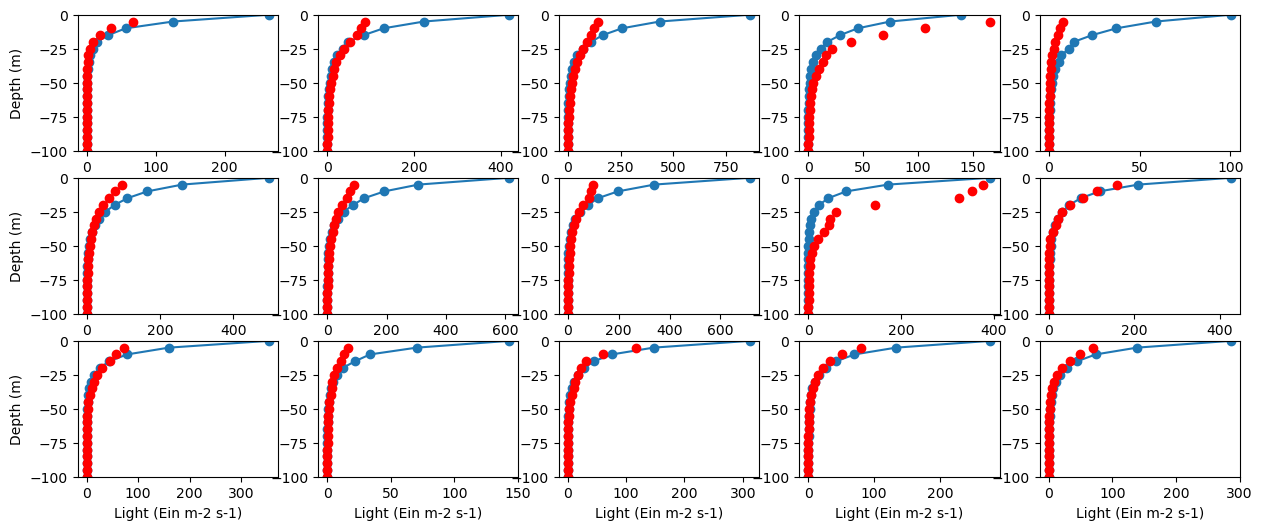

In [11]:
# Plot the first 15 profiles of modeled vs measured light
plt.figure(figsize=(15,6))
for j in range(15):
    example_tag = Inputs_ct182.TAG_ID[j]
    example_profile = Inputs_ct182.PROFILE_NUM[j]
    example_data = comparison_all_profiles_ct182[(comparison_all_profiles_ct182['Tag_ID'] == example_tag) &
                                            (comparison_all_profiles_ct182['Profile'] == example_profile)]
    plt.subplot(3, 5, j+1)
    plt.plot(example_data['PAR_modeled'], -example_data['Depth_modeled'], '-o')
    plt.plot(example_data['Light_measured'], -example_data['Depth_modeled'], 'ro')
    # plt.plot(example_data['Light_measured_fitted_interp'], -example_data['Depth_modeled'], 'g-', linewidth=2)
    plt.xlabel('Light (Ein m-2 s-1)')
    plt.ylabel('Depth (m)')
    # plt.title('{}, Profile: {}'.format(example_tag, example_profile))     
    plt.ylim(-100,0)
    # plt.legend(['Modeled PAR','Measured Light'])
    # Show y labels and ticks only on left plots
    if j % 5 != 0:
        plt.ylabel('')
        # plt.yticks([])
    # Show x labels only on bottom plots
    if j < 5:
        plt.xlabel('')
        # plt.xticks([])

Text(0.5, 1.0, 'SealTag Profiles Colored by Solar Altitude')

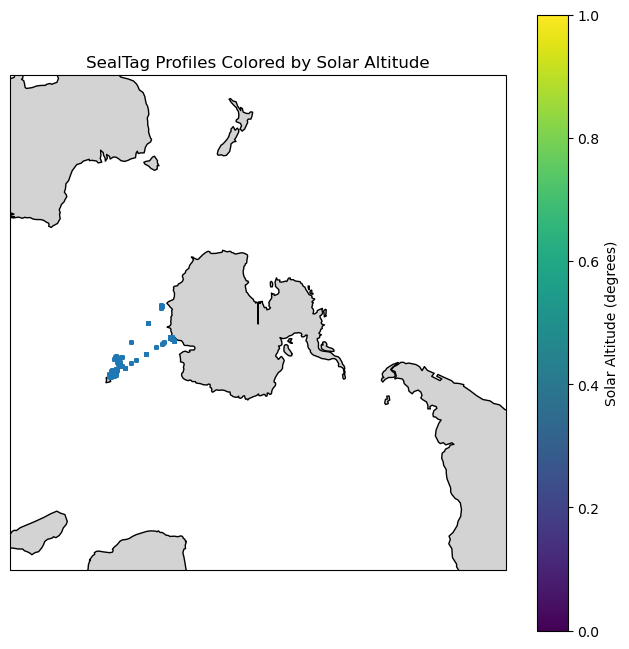

In [12]:
# Plot a polar stereographic map of all profiles colored by Solar Altitude
plt.figure(figsize=(8,8))
import cartopy.crs as ccrs
import cartopy.feature as cfeature
ax = plt.axes(projection=ccrs.Stereographic(central_latitude=-90, central_longitude=180))
ax.set_extent([-180, 180, -90, -30], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black', facecolor='lightgray')
sc = ax.scatter(comparison_all_profiles_ct182['Lon'], comparison_all_profiles_ct182['Lat'], transform=ccrs.PlateCarree(),s=5)
plt.colorbar(sc, label='Solar Altitude (degrees)')
plt.title('SealTag Profiles Colored by Solar Altitude')

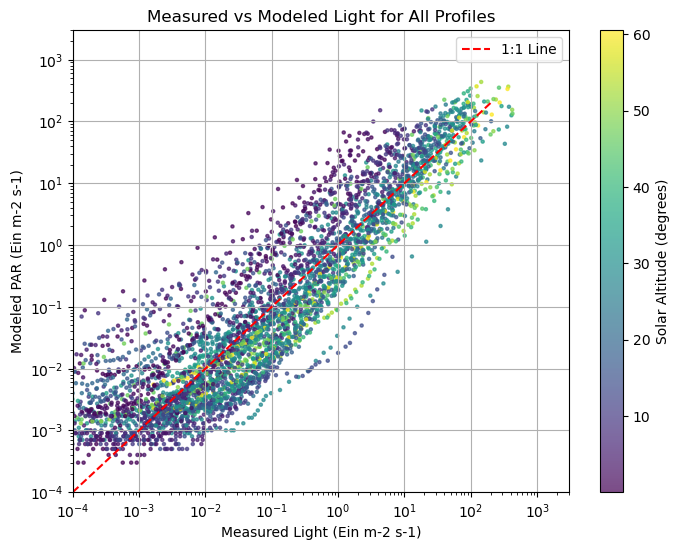

Light Linear Model: Slope=0.830, Intercept=3.114, R2=0.511, RMSE=19.9860, p=0.715


In [13]:
# Scatter plot of measured vs modeled light for all profiles (log log scale)
plt.figure(figsize=(8,6))
sc = plt.scatter(comparison_all_profiles_ct182['Light_measured'], comparison_all_profiles_ct182['PAR_modeled'], c=comparison_all_profiles_ct182['SolarAlt'], cmap='viridis', alpha=0.7, s=5)
plt.colorbar(sc, label='Solar Altitude (degrees)')
plt.plot([1e-4, 200], [1e-4, 200], 'r--', label='1:1 Line')
plt.legend()
plt.xlabel('Measured Light (Ein m-2 s-1)')
plt.ylabel('Modeled PAR (Ein m-2 s-1)')
plt.title('Measured vs Modeled Light for All Profiles')
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-4, 3000)
plt.ylim(1e-4, 3000)
plt.show()

# Display linear model statistics between measured and modeled light
from sklearn.metrics import r2_score, mean_squared_error
import math
light_measured = comparison_all_profiles_ct182['Light_measured'].values
par_modeled = comparison_all_profiles_ct182['PAR_modeled'].values
# Remove nans
valid_idx = ~np.isnan(light_measured) & ~np.isnan(par_modeled)
light_measured = light_measured[valid_idx]
par_modeled = par_modeled[valid_idx]
# Linear regression
slope, intercept = np.polyfit(light_measured, par_modeled, 1)
par_modeled_pred = slope * light_measured + intercept
r2 = r2_score(par_modeled, par_modeled_pred)
rmse = math.sqrt(mean_squared_error(par_modeled, par_modeled_pred))
p_value = np.corrcoef(light_measured, par_modeled)[0,1]
print('Light Linear Model: Slope={:.3f}, Intercept={:.3f}, R2={:.3f}, RMSE={:.4f}, p={:.3f}'.format(slope, intercept, r2, rmse, p_value))

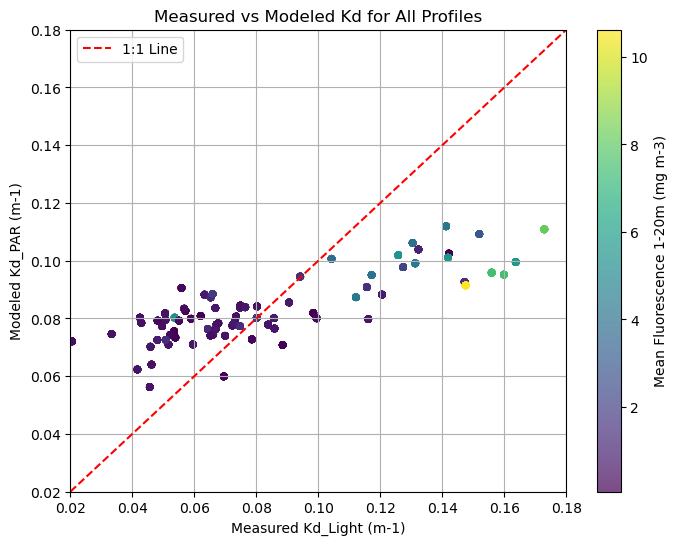

Kd Linear Model: Slope=0.236, Intercept=0.063, R2=0.579, RMSE=0.0077 m-1, p=0.761


In [14]:
# Scatter plot of measured vs modeled Kd for all profiles (log log scale)
plt.figure(figsize=(8,6))
sc = plt.scatter(comparison_all_profiles_ct182['Kd_measured_1_20m'], comparison_all_profiles_ct182['Kd_modeled_1_20m'], c=comparison_all_profiles_ct182['Fluo_measured_mean_1_20m'], cmap='viridis', alpha=0.7, s=20)
plt.colorbar(sc, label='Mean Fluorescence 1-20m (mg m-3)')
plt.plot([0.02, 0.18], [0.02, 0.18], 'r--', label='1:1 Line')
plt.legend()
plt.xlabel('Measured Kd_Light (m-1)')
plt.ylabel('Modeled Kd_PAR (m-1)')
plt.title('Measured vs Modeled Kd for All Profiles')
plt.grid()
# plt.xscale('log')
# plt.yscale('log')
plt.xlim(0.02, 0.18)
plt.ylim(0.02, 0.18)
plt.show()

# Display linear model statistics between measured and modeled Kd
from sklearn.metrics import r2_score, mean_squared_error
import math
kd_measured = comparison_all_profiles_ct182['Kd_measured_1_20m'].values
kd_modeled = comparison_all_profiles_ct182['Kd_modeled_1_20m'].values
# Remove nans
valid_idx = ~np.isnan(kd_measured) & ~np.isnan(kd_modeled)
kd_measured = kd_measured[valid_idx]
kd_modeled = kd_modeled[valid_idx]
# Linear regression
slope, intercept = np.polyfit(kd_measured, kd_modeled, 1)
kd_modeled_pred = slope * kd_measured + intercept
r2 = r2_score(kd_modeled, kd_modeled_pred)
rmse = math.sqrt(mean_squared_error(kd_modeled, kd_modeled_pred))
p_value = np.corrcoef(kd_measured, kd_modeled)[0,1]
print('Kd Linear Model: Slope={:.3f}, Intercept={:.3f}, R2={:.3f}, RMSE={:.4f} m-1, p={:.3f}'.format(slope, intercept, r2, rmse, p_value))

### MEOP tags (2018–2023)

In [179]:
# Create combined matchups per profile
df = COMBINE_MATCHUPS_PER_PROFILE("/SAT_MATCHUPS/MEOP_satellite_matchups.csv")

In [180]:
# Run SOCA-LIGHT model
SOCA_LIGHT_SRDL("MEOP_2", "/SAT_MATCHUPS/MEOP_satellite_matchups_combinedProfiles.csv")

AttributeError: 'DataFrame' object has no attribute 'SATELLITE'

In [ ]:
# Create a comparison dataset between measured light and modeled PAR
# comparison_df = CREATE_COMPARISON_DF("MEOP", "/SAT_MATCHUPS/MEOP_satellite_matchups.csv")
comparison_df_halfmld = CREATE_COMPARISON_DF("MEOP_HALFMLD", "/SAT_MATCHUPS/MEOP_satellite_matchups.csv")

In [ ]:
# Create a comparison dataset between measured light and modeled light
# for all profiles and save as a csv file
from datetime import datetime

comparison_all_profiles_ct182 = pd.DataFrame()
for i in np.arange(len(Inputs_ct182)):
    SEALTAG_NC_FILE = Inputs_ct182.SEALTAG_NC_FILE[i]
    PROFILE = Inputs_ct182.PROFILE_NUM[i]
    PAR_output_file = (''.join([str(PAR_OUT_PATH_ct182),'/',str(Inputs_ct182.TAG_ID[i]),'_',str(PROFILE),'_PAR.txt']))
    
    if os.path.isfile(SEALTAG_NC_FILE) and os.path.isfile(PAR_output_file):
        # LOAD THE SEALTAG file
        NC= NetCDFFile(str(SEALTAG_NC_FILE))
        profile_info_file = SEALTAG_NC_FILE.replace('_PROCESSED.nc','_ProfileInfo.xlsx')
        profile_info = pd.read_excel(profile_info_file, sheet_name='General')
        profile_info_PhotoPhys = pd.read_excel(profile_info_file, sheet_name='PhotoPhys')
        
        # Load modeled PAR profile
        db_par = pd.read_csv(PAR_output_file)
        depth_modeled = db_par['depth'].values
        PAR_modeled = db_par['PAR_ADJUSTED'].values
        # Kd from modeled PAR
        kd_modeled_profile = -np.gradient(np.log(PAR_modeled), depth_modeled)
        kd_modeled = np.mean(kd_modeled_profile[1:20])  # Mean Kd from 1 to 50 m
        
        # Read measured light profile
        light_measured = NC.variables['LIGHT_DRK'][PROFILE-1,:]
        pres_measured = NC.variables['PRES'][PROFILE-1,:]
        light_measured = light_measured.filled(fill_value=np.nan)
        pres_measured = pres_measured.filled(fill_value=np.nan)
        # Kd from measured light
        kd_measured_profile = NC.variables['KD_LIGHT'][PROFILE-1,:]
        kd_measured = np.nanmean(kd_measured_profile[1:20])  # Mean Kd from 1 to 50 m, omit nans
        
        # Interpolate measured light to the modeled depths
        light_measured = np.interp(depth_modeled, pres_measured, light_measured, left=np.nan, right=np.nan)
        
        # Create a combined dataframe for comparison
        comparison_df = pd.DataFrame({
            'Depth_modeled': depth_modeled,
            'PAR_modeled': PAR_modeled,
            'Light_measured': light_measured
        })
        comparison_df['PAR_modeled_mean_1_20m'] = np.nanmean(PAR_modeled[1:20])
        comparison_df['Light_measured_mean_1_20m'] = np.nanmean(light_measured[1:20])
        comparison_df['Kd_modeled_1_20m'] = kd_modeled
        comparison_df['Kd_measured_1_20m'] = kd_measured
        comparison_df['Fluo_measured_mean_1_20m'] = np.nanmean(NC.variables['FLUO_DRK_NPQ'][PROFILE-1,1:21])
        comparison_df['SlopeFactor'] = profile_info_PhotoPhys['SlopeFactor_linfit'].values[PROFILE-1]
        comparison_df['Tag_ID'] = Inputs_ct182.TAG_ID[i]
        comparison_df['Profile'] = PROFILE
        comparison_df['SolarAlt'] = profile_info['SolarAlt'].values[PROFILE-1]
        comparison_df['Lat'] = profile_info['Lat'].values[PROFILE-1]
        comparison_df['Lon'] = profile_info['Lon'].values[PROFILE-1]
        comparison_df['Bathy'] = profile_info['Bathymetry_ETOPO'].values[PROFILE-1]
        comparison_df['DOY'] = int(pd.to_datetime(profile_info['Date'].values[PROFILE-1]).strftime("%j"))
        
        # Append to the overall comparison dataset
        comparison_all_profiles_ct182 = pd.concat([comparison_all_profiles_ct182, comparison_df], ignore_index=True)
        
# Set all measured values nan that are less than 10^-9
comparison_all_profiles_ct182.loc[comparison_all_profiles_ct182['Light_measured'] < 1e-9, 'Light_measured'] = np.nan

# Export the comparison dataset to CSV
comparison_output_file = (''.join(['Comparison_Modeled_vs_Measured_Light_All_Profiles_ct182.csv']))
comparison_all_profiles_ct182.to_csv(comparison_output_file, index=False)

In [146]:
# Define data mask
data_mask = (
    (comparison_df['N_VALID_PIXELS'] >= 5) &
    (comparison_df['CV_PAR'] <= 0.3) &
    (comparison_df['SolarAlt'] >= 15) &
    (comparison_df['SolarAlt'] <= 60) &
    (comparison_df['Bathy'] <= -0)
)

# Choose df
plot_df = comparison_df

In [ ]:
# Plot a polar stereographic map of all profiles
plt.figure(figsize=(8,8))
import cartopy.crs as ccrs
import cartopy.feature as cfeature
ax = plt.axes(projection=ccrs.Stereographic(central_latitude=-90, central_longitude=180))
ax.set_extent([-180, 180, -90, -30], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black', facecolor='lightgray')
sc = ax.scatter(comparison_df.loc[~data_mask, 'Lon'], comparison_df.loc[~data_mask, 'Lat'], transform=ccrs.PlateCarree(),s=1, color='red')
sc = ax.scatter(comparison_df.loc[data_mask, 'Lon'], comparison_df.loc[data_mask, 'Lat'], transform=ccrs.PlateCarree(),s=1)

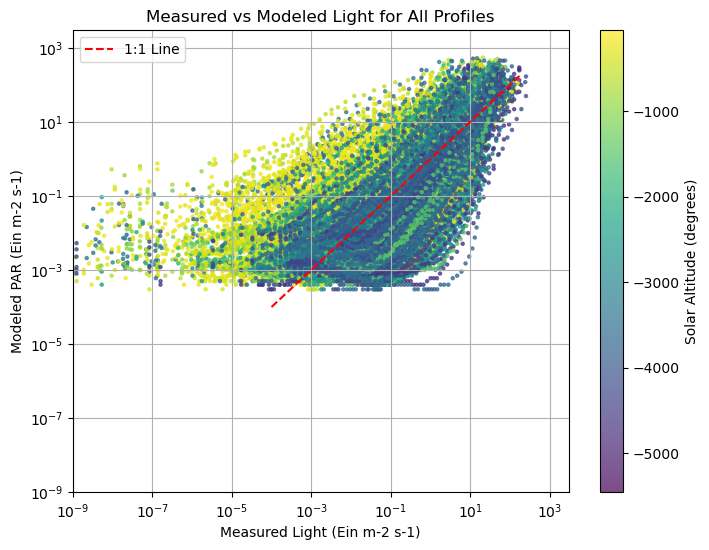

Light Linear Model: Slope=1.540, Intercept=3.534, R2=0.217, RMSE=28.3233, p=0.466


In [147]:
# Scatter plot of measured vs modeled light for all profiles (log log scale)
plt.figure(figsize=(8,6))
sc = plt.scatter(plot_df['Light_measured'], plot_df['PAR_modeled'], c=plot_df['Bathy'], cmap='viridis', alpha=0.7, s=5)
plt.colorbar(sc, label='Solar Altitude (degrees)')
plt.plot([1e-4, 200], [1e-4, 200], 'r--', label='1:1 Line')
plt.legend()
plt.xlabel('Measured Light (Ein m-2 s-1)')
plt.ylabel('Modeled PAR (Ein m-2 s-1)')
plt.title('Measured vs Modeled Light for All Profiles')
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-9, 3000)
plt.ylim(1e-9, 3000)
plt.show()

# Display linear model statistics between measured and modeled light
light_measured = plot_df['Light_measured'].values
par_modeled = plot_df['PAR_modeled'].values
# Remove nans
valid_idx = ~np.isnan(light_measured) & ~np.isnan(par_modeled)
light_measured = light_measured[valid_idx]
par_modeled = par_modeled[valid_idx]
# Linear regression
slope, intercept = np.polyfit(light_measured, par_modeled, 1)
par_modeled_pred = slope * light_measured + intercept
r2 = r2_score(par_modeled, par_modeled_pred)
rmse = math.sqrt(mean_squared_error(par_modeled, par_modeled_pred))
p_value = np.corrcoef(light_measured, par_modeled)[0,1]
print('Light Linear Model: Slope={:.3f}, Intercept={:.3f}, R2={:.3f}, RMSE={:.4f}, p={:.3f}'.format(slope, intercept, r2, rmse, p_value))

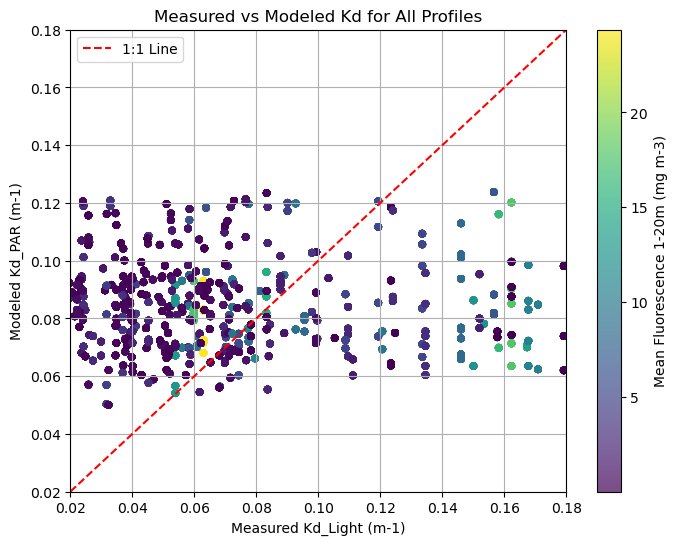

Kd Linear Model: Slope=-0.023, Intercept=0.086, R2=0.004, RMSE=0.0161 m-1


In [89]:
# Scatter plot of measured vs modeled Kd for all profiles (log log scale)
plt.figure(figsize=(8,6))
sc = plt.scatter(comparison_df['Kd_measured_1_20m'], comparison_df['Kd_modeled_1_20m'], c=comparison_df['Fluo_measured_mean_1_20m'], cmap='viridis', alpha=0.7, s=20)
plt.colorbar(sc, label='Mean Fluorescence 1-20m (mg m-3)')
plt.plot([0.02, 0.18], [0.02, 0.18], 'r--', label='1:1 Line')
plt.legend()
plt.xlabel('Measured Kd_Light (m-1)')
plt.ylabel('Modeled Kd_PAR (m-1)')
plt.title('Measured vs Modeled Kd for All Profiles')
plt.grid()
# plt.xscale('log')
# plt.yscale('log')
plt.xlim(0.02, 0.18)
plt.ylim(0.02, 0.18)
plt.show()

# Display linear model statistics between measured and modeled Kd
from sklearn.metrics import r2_score, mean_squared_error
import math
kd_measured = comparison_df['Kd_measured_1_20m'].values
kd_modeled = comparison_df['Kd_modeled_1_20m'].values
# Remove nans
valid_idx = ~np.isnan(kd_measured) & ~np.isnan(kd_modeled)
kd_measured = kd_measured[valid_idx]
kd_modeled = kd_modeled[valid_idx]
# Linear regression
slope, intercept = np.polyfit(kd_measured, kd_modeled, 1)
kd_modeled_pred = slope * kd_measured + intercept
r2 = r2_score(kd_modeled, kd_modeled_pred)
rmse = math.sqrt(mean_squared_error(kd_modeled, kd_modeled_pred))
p_value = np.corrcoef(kd_measured, kd_modeled)[0,1]
print('Kd Linear Model: Slope={:.3f}, Intercept={:.3f}, R2={:.3f}, RMSE={:.4f} m-1'.format(slope, intercept, r2, rmse))

### ct182 and 2018–2023 combined

In [16]:
def type2_regression_complete(x, y):
    """
    Complete Type 2 regression with multiple regression types
    Similar to R's lmodel2 package
    """
    valid_idx = ~np.isnan(x) & ~np.isnan(y)
    x_clean = x[valid_idx]
    y_clean = y[valid_idx]
    
    n = len(x_clean)
    
    # Basic statistics
    x_mean = np.mean(x_clean)
    y_mean = np.mean(y_clean)
    sx = np.std(x_clean, ddof=1)  # sample standard deviation
    sy = np.std(y_clean, ddof=1)
    r = np.corrcoef(x_clean, y_clean)[0, 1]
    
    # Different regression types
    results = {}
    
    # 1. Ordinary Least Squares (OLS) - Type 1
    slope_ols = r * sy / sx
    intercept_ols = y_mean - slope_ols * x_mean
    results['OLS'] = (slope_ols, intercept_ols)
    
    # 2. Major Axis (MA) - Type 2
    slope_ma = np.sign(r) * sy / sx
    intercept_ma = y_mean - slope_ma * x_mean
    results['MA'] = (slope_ma, intercept_ma)
    
    # 3. Standard Major Axis (SMA) - same as MA
    results['SMA'] = results['MA']
    
    # 4. Reduced Major Axis (RMA) - another name for MA
    results['RMA'] = results['MA']
    
    # Calculate fit statistics
    y_pred_ma = slope_ma * x_clean + intercept_ma
    r2 = r**2
    rmse = np.sqrt(np.mean((y_clean - y_pred_ma)**2))
    
    return results, r2, rmse, r, n

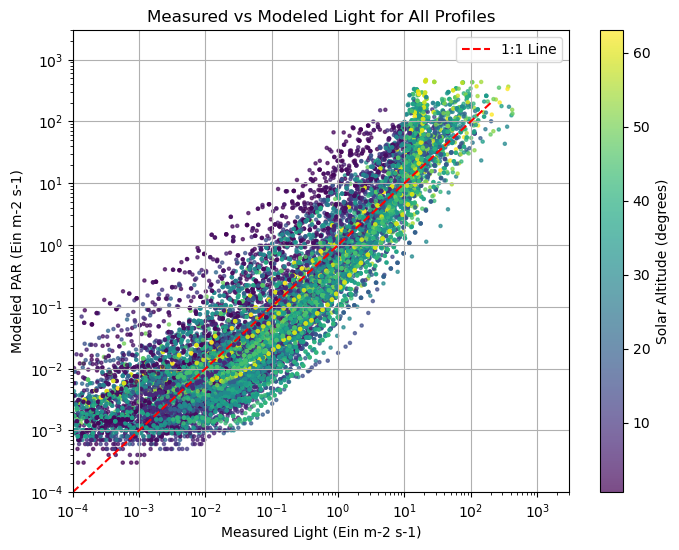

Light Type 2 Linear Model: Slope=1.247, Intercept=4.085, R2=0.334, RMSE=30.5951


In [27]:
# Scatter plot of measured vs modeled light for all profiles (log log scale)
plt.figure(figsize=(8,6))
sc = plt.scatter(comparison_all_profiles_ct182['Light_measured'], comparison_all_profiles_ct182['PAR_modeled'], c=comparison_all_profiles_ct182['SolarAlt'], cmap='viridis', alpha=0.7, s=5)
sc = plt.scatter(comparison_all_profiles_pre2023['Light_measured'], comparison_all_profiles_pre2023['PAR_modeled'], c=comparison_all_profiles_pre2023['SolarAlt'], cmap='viridis', alpha=0.7, s=5)
plt.colorbar(sc, label='Solar Altitude (degrees)')
plt.plot([1e-4, 200], [1e-4, 200], 'r--', label='1:1 Line')
plt.legend()
plt.xlabel('Measured Light (Ein m-2 s-1)')
plt.ylabel('Modeled PAR (Ein m-2 s-1)')
plt.title('Measured vs Modeled Light for All Profiles')
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-4, 3000)
plt.ylim(1e-4, 3000)
plt.show()

# Display linear model statistics between measured and modeled light
results, r2, rmse, r, n = type2_regression_complete(
    np.concatenate([comparison_all_profiles_pre2023['Light_measured'].values, comparison_all_profiles_ct182['Light_measured'].values]),
    np.concatenate([comparison_all_profiles_pre2023['PAR_modeled'].values, comparison_all_profiles_ct182['PAR_modeled'].values])
)

slope_type2, intercept_type2 = results['OLS']
r2 = r2
rmse = rmse
r = r

print('Light Type 2 Linear Model: Slope={:.3f}, Intercept={:.3f}, R2={:.3f}, RMSE={:.4f}'.format(slope_type2, intercept_type2, r2, rmse, r))

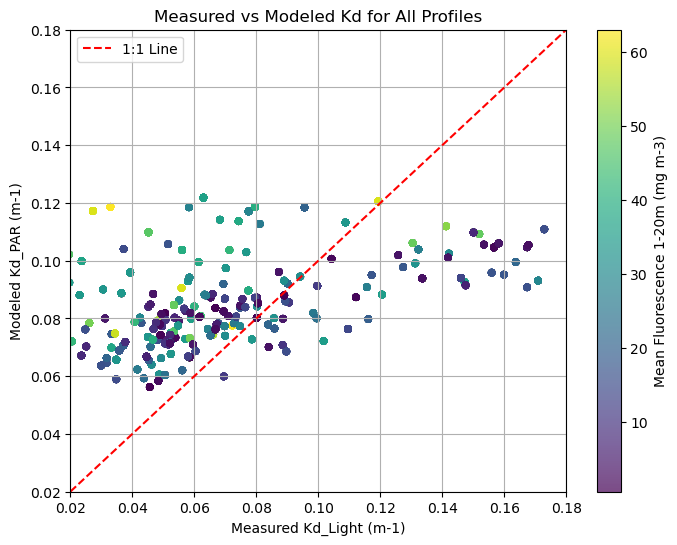

Light Type 2 Linear Model: Slope=0.170, Intercept=0.074, R2=0.258, RMSE=0.0155


In [46]:
SunAngleMask = comparison_all_profiles_pre2023['SolarAlt'] > 15

# Scatter plot of measured vs modeled Kd for all profiles (log log scale)
plt.figure(figsize=(8,6))
sc = plt.scatter(comparison_all_profiles_ct182['Kd_measured_1_20m'], comparison_all_profiles_ct182['Kd_modeled_1_20m'], c=comparison_all_profiles_ct182['SolarAlt'], cmap='viridis', alpha=0.7, s=20)
sc = plt.scatter(comparison_all_profiles_pre2023['Kd_measured_1_20m'], comparison_all_profiles_pre2023['Kd_modeled_1_20m'], c=comparison_all_profiles_pre2023['SolarAlt'], cmap='viridis', alpha=0.7, s=20)
plt.colorbar(sc, label='Mean Fluorescence 1-20m (mg m-3)')
plt.plot([0.02, 0.18], [0.02, 0.18], 'r--', label='1:1 Line')
plt.legend()
plt.xlabel('Measured Kd_Light (m-1)')
plt.ylabel('Modeled Kd_PAR (m-1)')
plt.title('Measured vs Modeled Kd for All Profiles')
plt.grid()
# plt.xscale('log')
# plt.yscale('log')
plt.xlim(0.02, 0.18)
plt.ylim(0.02, 0.18)
plt.show()

# Display linear model statistics between measured and modeled light
results, r2, rmse, r, n = type2_regression_complete(
    np.concatenate([comparison_all_profiles_pre2023['Kd_measured_1_20m'].values, comparison_all_profiles_ct182['Kd_measured_1_20m'].values]),
    np.concatenate([comparison_all_profiles_pre2023['Kd_modeled_1_20m'].values, comparison_all_profiles_ct182['Kd_modeled_1_20m'].values])
)

slope_type2, intercept_type2 = results['OLS']
r2 = r2
rmse = rmse
r = r

print('Light Type 2 Linear Model: Slope={:.3f}, Intercept={:.3f}, R2={:.3f}, RMSE={:.4f}'.format(slope_type2, intercept_type2, r2, rmse, r))